RQ5 – Shipping cost, region, and profitability

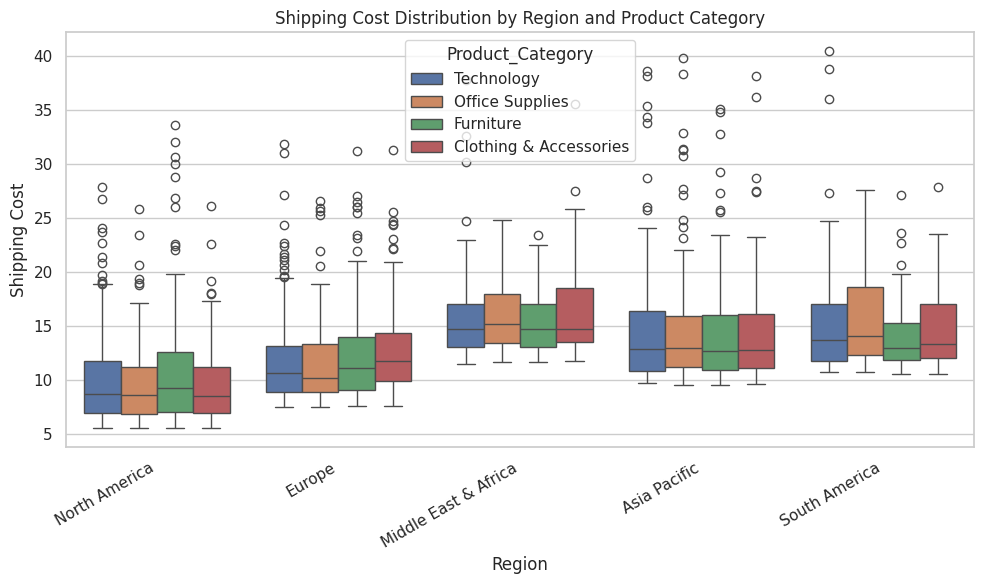

In [13]:
# RQ5: Shipping cost, region, and profitability

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np

# -------------------
# 1. Load data
# -------------------
DATA_PATH = Path("/kaggle/input/datasets/bibirehana/global-e-commarce-sales-data-analysis/global_ecommerce_sales.csv")
df = pd.read_csv(DATA_PATH)

OUTPUT_DIR = Path("./rq5_outputs")
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

# -------------------
# 1. Aggregate by Region and Product_Category
# -------------------
ship_profit = (
    df.groupby(['Region', 'Product_Category'], as_index=False)
      .agg(
          Avg_Shipping_Cost=('Shipping_Cost', 'mean'),
          Avg_Profit=('Profit', 'mean'),
          Order_Count=('Order_ID', 'nunique')
      )
)

ship_profit.to_csv(OUTPUT_DIR / "RQ5_Table_Shipping_Profit_ByRegionCategory.csv", index=False)

# -------------------
# 2. Boxplot of shipping cost
# -------------------
sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x='Region',
    y='Shipping_Cost',
    hue='Product_Category'
)
plt.title("Shipping Cost Distribution by Region and Product Category")
plt.xlabel("Region")
plt.ylabel("Shipping Cost")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "RQ5_Figure1_ShippingCost_Boxplot.pdf", format="pdf")
plt.show()
plt.close()

### Interpretation of chart.

- Shipping costs vary significantly across regions, with some regions consistently showing higher median shipping costs than others.

- Asia Pacific and Europe generally exhibit higher shipping cost ranges, suggesting longer delivery distances, higher logistics expenses, or heavier product mixes.

- North America and South America show moderate shipping costs, with narrower spreads indicating more predictable logistics patterns.

- Middle East & Africa displays the widest variability, implying inconsistent shipping conditions or diverse product types being shipped.

- Furniture products tend to have the highest shipping costs, as expected due to size and weight.

- Office Supplies and Clothing & Accessories show the lowest shipping costs, reflecting lighter and smaller items.

- Technology products fall in the mid‑range, with moderate but consistent shipping costs across regions.

- Overall, product category strongly influences shipping cost, but regional logistics amplify or reduce these differences.